# Machine Learning: previsão de preços

Treinaremos um modelo de regressão para estimar o preço dos imóveis.

### Importar as bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')

### Carregar os dados

In [2]:
df = pd.read_csv('../dataset/limpo.csv')

### Selecionar as variáveis

Usamos características originais; endereço, data e `price_per_sqft` ficam fora para evitar ruído e vazamento do preço.

In [3]:
variaveis_numericas = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
    'yr_built', 'yr_renovated'
]
variaveis_categoricas = ['city', 'statezip']

X = pd.get_dummies(
    df[variaveis_numericas + variaveis_categoricas],
    columns=variaveis_categoricas
)
y = df['price']

### Separar treino e teste

Usamos 80% dos imóveis no treino e reservamos 20% para a avaliação final.

In [4]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Imóveis para treino:', len(X_treino))
print('Imóveis para teste:', len(X_teste))

Imóveis para treino: 3602
Imóveis para teste: 901


### Padronizar os números

O StandardScaler ajusta apenas o treino e coloca as colunas numéricas na mesma escala.

In [5]:
scaler = StandardScaler()

X_treino[variaveis_numericas] = scaler.fit_transform(
    X_treino[variaveis_numericas]
)
X_teste[variaveis_numericas] = scaler.transform(
    X_teste[variaveis_numericas]
)

### Treinar e ajustar o modelo

A busca testa oito combinações simples e escolhe a Random Forest com o menor MAE médio.

In [6]:
modelo = RandomForestRegressor(random_state=42, n_jobs=-1)

parametros = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5]
}

busca = GridSearchCV(
    modelo,
    parametros,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1
)
busca.fit(X_treino, y_treino)

print('Melhores parâmetros:', busca.best_params_)

Melhores parâmetros: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


### Avaliar o modelo

MAE e RMSE medem os erros; R² mostra quanto da variação dos preços foi explicada.

In [7]:
previsoes = busca.predict(X_teste)

mae = mean_absolute_error(y_teste, previsoes)
rmse = mean_squared_error(y_teste, previsoes) ** 0.5
r2 = r2_score(y_teste, previsoes)

print(f'MAE: {mae:,.2f}')
print(f'RMSE: {rmse:,.2f}')
print(f'R²: {r2:.3f}')

MAE: 92,400.79
RMSE: 149,843.86
R²: 0.716


### Comparar preços reais e previstos

Quanto mais perto da linha vermelha, mais próxima a previsão está do preço real.

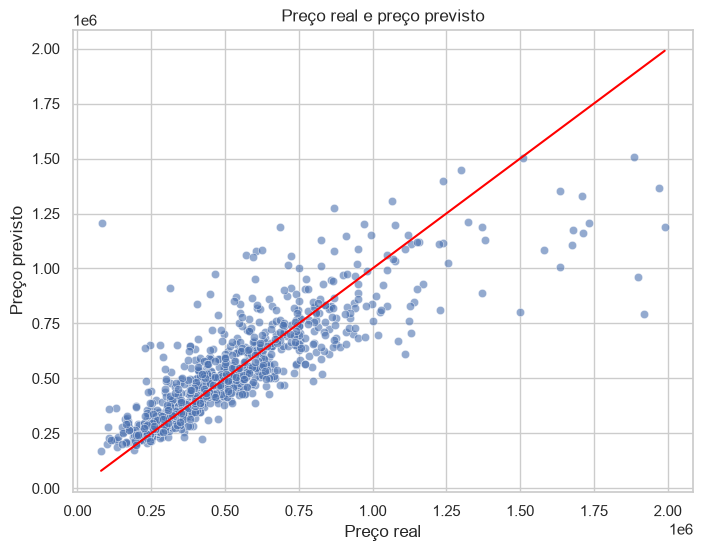

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_teste, y=previsoes, alpha=0.6)
plt.plot(
    [y_teste.min(), y_teste.max()],
    [y_teste.min(), y_teste.max()],
    color='red'
)
plt.title('Preço real e preço previsto')
plt.xlabel('Preço real')
plt.ylabel('Preço previsto')
plt.show()

### Conclusão

As métricas e o gráfico resumem o desempenho do modelo em imóveis que ele não viu no treino.